# <span style="color:#336699">Introdução ao Serviço de Acesso a Séries Temporais - WTSS</span>
<hr style="border:2px solid #0077b9;">

<br/>

<div style="text-align: center;font-size: 90%;">
    Gilberto Ribeiro de Queiroz<sup><a href="https://orcid.org/0000-0001-7534-0219"><i class="fab fa-lg fa-orcid" style="color: #a6ce39"></i></a></sup>, Karine Reis Ferreira<sup><a href="https://orcid.org/0000-0003-2656-5504"><i class="fab fa-lg fa-orcid" style="color: #a6ce39"></i></a></sup>, Marcos Adami<sup><a href="https://orcid.org/0000-0003-4247-4477"><i class="fab fa-lg fa-orcid" style="color: #a6ce39"></i></a></sup>, Thales Sehn Körting<sup><a href="https://orcid.org/0000-0002-0876-0501"><i class="fab fa-lg fa-orcid" style="color: #a6ce39"></i></a></sup>, Gabriel Sansigolo<sup><a href="https://orcid.org/0000-0003-0789-5858"><i class="fab fa-lg fa-orcid" style="color: #a6ce39"></i></a></sup>
    <br/><br/>
    Divisão de Observação da Terra e Geoinformática, Instituto Nacional de Pesquisas Espaciais (INPE)
    <br/>
    Avenida dos Astronautas, 1758, Jardim da Granja, São José dos Campos, SP 12227-010, Brazil
    <br/><br/>
    Contact: <a href="https://geo-credito-rural.github.io/">Equipe - Geo Credito Rural</a>
    <br/><br/>
    Última Atualização: 05 de Maio de 2026
</div>

<br/>

<div style="text-align: justify;  margin-left: 25%; margin-right: 25%;">
    <b>Resumo.</b> Este Jupyter Notebook é parte do material da capacitação "Monitoramento de Operações de Crédito Rural por meio de Geotecnologias" disponível em <a href="https://geo-credito-rural.github.io/">Geo Credito Rural</a>. O Web Time Series Service ou WTSS é um serviço web voltado para extração de séries temporais a partir de imagens de sensoriamento remoto organizadas na forma de cubos de dados. Este Jupyter Notebook apresenta uma visão geral desse serviço na linguagem Python para manipulação de séries temporais extraídas dos produtos de dados de sensoriamento remoto disponíveis na <em>Plataforma Brazil Data Cube</em>. Os estudos de caso serão aplicados a áreas de glebas do Sicor.
</div>


# Introdução
<hr style="border:1px solid #0077b9;">

<br/>

O **W**eb **T**ime **S**eries **S**ervice ou **WTSS** é um serviço web voltado para extração de séries temporais a partir de imagens de sensoriamento remoto organizadas na forma de cubos de dados. Dada uma localização ou região do espaço geográfico e um intervalo de tempo, a API deste serviço permite que os clientes requisitem as séries temporais para os produtos de dados do [Brazil Data Cube](https://data.inpe.br/bdc/web/) (Figura 1). Esse serviço pode ser utilizado a partir de pacotes construídos para linguagens de programação como [Python](https://github.com/brazil-data-cube/wtss.py) e [R](https://github.com/e-sensing/Rwtss), ou pode ser usado diretamente em interfaces gráficas com o usuário, por meio de [plugin do QGIS](https://github.com/brazil-data-cube/wtss-qgis) ou de componente gráfico de aplicações como o [Data Cube Explorer](https://data.inpe.br/bdc/explorer/) e [TerraCollect](https://data.inpe.br/bdc/terracollect/).

<center>
    <img src="https://geo-credito-rural.github.io/_images/overview.png" width="80%" />
    <br/>
    <b>Figura 1</b> - Visão geral do serviço WTSS.
</center>


<br/><br/>


O WTSS é baseado em três operações (Figura 2):
- `list_coverages`: Retorna a lista de produtos de dados, isto é, cubos de dados, disponíveis no serviço para consulta.

- `describe_coverage`: Retorna metadados básicos de um determinado cubo de dados.

- `time_series`: Consulta a lista de valores associadas a uma dada localização ou região do espaço geográfico e um intervalo de tempo.


**Nota:** O projeto original do WTSS utilizava a nomenclatura de *coverage* para se referir aos produtos de dados regulares no espaço e no tempo, como é o caso dos cubos de dados do Brazil Data Cube.


<br/><br/>


<center>    
    <img src="https://raw.githubusercontent.com/brazil-data-cube/code-gallery/master/img/wtss/wtss-operations.png?raw=true" align="center" width="768"/>
    <br/>
    <b>Figura 2</b> - Operações do Serviço WTSS.
    <br/>
    <b>Fonte</b>: Galeria de Código do Brazil Data Cube.
</center>


<br/><br/>


Os pacotes para a linguagem Python e R fornecem abstrações próprias para utilização dessas operações. Este Jupyter Notebook apresenta como utilizar este serviço na linguagem Python.

# Cliente WTSS no Python
<hr style="border:1px solid #0077b9;">

<br/>

Para demonstrar o acesso aos produtos de dados do Brazil Data Cube, iremos utilizar uma bibloteca de software livre para Python denominada [wtss.py](https://github.com/brazil-data-cube/wtss.py) (`wtss`).

Para instalar essa biblioteca no ambiente Jupyter, pode ser utilizado o seguinte comando `pip install`:

In [ ]:
!pip install git+https://github.com/brazil-data-cube/wtss.py@b-2.0

  Cloning https://github.com/brazil-data-cube/wtss.py (to revision b-2.0) to /tmp/pip-req-build-shhpg404
  Running command git clone --filter=blob:none --quiet https://github.com/brazil-data-cube/wtss.py /tmp/pip-req-build-shhpg404
  Running command git checkout -b b-2.0 --track origin/b-2.0
  Switched to a new branch 'b-2.0'
  Branch 'b-2.0' set up to track remote branch 'b-2.0' from 'origin'.
  Resolved https://github.com/brazil-data-cube/wtss.py to commit 19fb24c4ba02a060924a2ac9f8c2b14b434c231a
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for wtss: filename=wtss-2.0.0a4-py3-none-any.whl size=37336 sha256=156ef26b0d57751f93af987736a3e6ed7849b8f3ceade503ea4e86c323e9734c
  Stored in directory: /tmp/pip-ephem-wheel-cache-lfll4xc4/wheels/8c/4c/5f/7e0d6cdaf281cf8fe83aad456f8697f0f778e775a11bf8d706
Successfully built wtss


Uma vez instalada a biblioteca `wtss`, podemos carregar suas funcionalidades através do comando `import`, como mostrado abaixo:

In [ ]:
import wtss

Em geral, uma biblioteca do ecossistema Python possui uma constante especial para informar a versão da biblioteca carregada. Abaixo, apresentamos a versão carregada  da biblioteca `wtss`:

In [ ]:
wtss.__version__

'2.0.0a4'

# Bibliotecas Utilizadas no Jupyter Notebook
<hr style="border:1px solid #0077b9;">

<br/>

Iremos utilizar as seguintes bibliotecas:

- **Matplotlib:** Para visualização das séries temporais

- **Pandas:** Para ajustar o formato de apresentação dos DataFrames.

- **GeoPandas:** Para leitura dos dados relacionados às glebas que serão utilizadas nos exemplos.

- **shapely:** Para manipulação de geometrias.

- **pystac-client:** Para consultar imagens Sentinel-2 no catálogo de imagens do INPE.

- **ipyleaflet**: Para criação de mapas apresentando as glebas e as imagens recuperadas do catálogo.

In [ ]:
%matplotlib inline
import matplotlib

In [ ]:
import pandas as pd

pd.options.display.max_columns = None

In [ ]:
import geopandas as gpd

In [ ]:
import shapely

In [ ]:
# Área de exibição de camadas (mapa) e mapas base (basemaps)
from ipyleaflet import Map, basemaps

# Controles sobre o mapa
from ipyleaflet import FullScreenControl, LayersControl, ScaleControl, SplitMapControl, WidgetControl

# Tipos de Camadas
from ipyleaflet import GeoJSON, TileLayer

# Layout
from ipywidgets import IntSlider, Layout

<img src="https://raw.githubusercontent.com/brazil-data-cube/code-gallery/master/img/wtss/list-coverages.png?raw=true" align="right" width="220"/>

# Verificando os Produtos de Dados Disponíveis no Serviço
<hr style="border:1px solid #0077b9;">

<br/><br/>

O endereço do serviço WTSS do BDC é https://data.inpe.br/bdc/wtss/v4/. Para descobrir os cubos de dados disponíveis para acesso nesse serviço,
é possível utilizar a classe `WTSS` do pacote `wtss`. Ao criar um objeto dessa classe, devemos informar a URL do serviço:

In [ ]:
servico = wtss.WTSS('https://data.inpe.br/bdc/wtss/v4/')

O WTSS utiliza a terminologia de **coverages** para se referir aos cubos de dados do Brazil Data Cube. A propriedade `coverages` retorna uma lista com os identificadores dos cubos de dados, isto é, das *coverages*, que podem ser consultadas pelo serviço:

In [ ]:
servico.coverages

['CBERS4-MUX-2M-1',
 'CBERS4-WFI-16D-2',
 'CBERS-WFI-8D-1',
 'LANDSAT-16D-1',
 'mod11a2-6.1',
 'mod13q1-6.1',
 'myd11a2-6.1',
 'myd13q1-6.1',
 'S2-16D-2']

Repare que os identificadores retornados pela propriedade `coverages` são os mesmos usados no catálogo STAC. Seus significados podem ser consultados no [Data Cube Explorer](https://data.inpe.br/bdc/explorer/), ou no [STAC Browser](https://data.inpe.br/stac/browser/) ou diretamente no [serviço STAC](https://data.inpe.br/bdc/stac/).

**Observação:** A documentação da classe `WTSS` pode ser vista [aqui](https://wtss.readthedocs.io/en/latest/class_wtss.html).

<img src="https://raw.githubusercontent.com/brazil-data-cube/code-gallery/master/img/wtss/describe-coverage.png?raw=true" align="right" width="220"/>

# Recuperando os Metadados de um Produto
<hr style="border:1px solid #0077b9;">

<br/>

Os identificadores retornados pela propriedade `coverages` podem ser utilizados nas operações seguintes do serviço, tanto para recuperação de metadados quanto da série temporal. O operador `[]` em um objeto `WTSS` permite acessar o metadado de um cubo de dados específico. Por exemplo, vamos considerar o cubo de dados Sentinel-2, com resolução espacial de 10 metros e composição temporal de 16 dias. Este produto é identificado na lista anterior como `S2-16D-2`. Vamos recuperar seus metadados no serviço WTSS:

In [ ]:
cubo_s2 = servico['S2-16D-2']
cubo_s2

name,common name,description,min,max,nodata,scale,center_wavelength,full_width_half_max,data_type
CLEAROB,ClearOb,,,,0.0,1.0,,,uint8
TOTALOB,TotalOb,,,,0.0,1.0,,,uint8
PROVENANCE,Provenance,,,,-1.0,1.0,,,int16
SCL,quality,,,,0.0,1.0,,,uint8
B01,coastal,,,,0.0,0.0001,,,uint16
B02,blue,,,,0.0,0.0001,,,uint16
B04,red,,,,0.0,0.0001,,,uint16
B08,nir,,,,0.0,0.0001,,,uint16
B8A,nir08,,,,0.0,0.0001,,,uint16
B09,nir09,,,,0.0,0.0001,,,uint16


Os metadados acima são um subconjunto dos metadados disponíveis no STAC e incluem:

- nome do cubo de dados

In [ ]:
cubo_s2.name

'S2-16D-2'

- descrição:

In [ ]:
cubo_s2.description

'Earth Observation Data Cube generated from Copernicus Sentinel-2/MSI Level-2A product over Brazil. This dataset is provided in Cloud Optimized GeoTIFF (COG) file format. The dataset is processed with 10 meters of spatial resolution, reprojected and cropped to BDC_SM grid Version 2 (BDC_SM V2), considering a temporal compositing function of 16 days using the Least Cloud Cover First (LCF) best pixel approach.'

- Atributos (bandas ou índices espectrais):

In [ ]:
cubo_s2.attributes

[{'name': 'CLEAROB',
  'common_name': 'ClearOb',
  'scale': 1.0,
  'scale_add': None,
  'nodata': 0.0,
  'data_type': 'uint8',
  'resolution_x': 10.0,
  'resolution_y': 10.0,
  'min_value': 1.0,
  'max_value': 255.0},
 {'name': 'TOTALOB',
  'common_name': 'TotalOb',
  'scale': 1.0,
  'scale_add': None,
  'nodata': 0.0,
  'data_type': 'uint8',
  'resolution_x': 10.0,
  'resolution_y': 10.0,
  'min_value': 1.0,
  'max_value': 255.0},
 {'name': 'PROVENANCE',
  'common_name': 'Provenance',
  'scale': 1.0,
  'scale_add': None,
  'nodata': -1.0,
  'data_type': 'int16',
  'resolution_x': 10.0,
  'resolution_y': 10.0,
  'min_value': 1.0,
  'max_value': 366.0},
 {'name': 'SCL',
  'common_name': 'quality',
  'scale': 1.0,
  'scale_add': None,
  'nodata': 0.0,
  'data_type': 'uint8',
  'resolution_x': 10.0,
  'resolution_y': 10.0,
  'min_value': 0.0,
  'max_value': 11.0},
 {'name': 'B01',
  'common_name': 'coastal',
  'scale': 0.0001,
  'scale_add': None,
  'nodata': 0.0,
  'data_type': 'uint16',

- Retângulo envolvente da base de imagens do cubo de dados, representado como uma geometria do tipo `Polygon` da bibloteca `Shapely`.

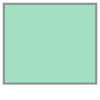

In [ ]:
cubo_s2.spatial_extent

- Instantes de tempo das obervações disponíveis no cubo.

In [ ]:
timeline = cubo_s2.timeline

ultima_data_disponivel = timeline[0]
primeira_data_disponivel = timeline[-1]

print(f'Intervalo: [{primeira_data_disponivel}, {ultima_data_disponivel}]')

Intervalo: [2026-04-07, 2017-01-01]


**Observação:** A documentação da classe `Coverage` pode ser vista [aqui](https://wtss.readthedocs.io/en/latest/class_coverage.html).

<img src="https://raw.githubusercontent.com/brazil-data-cube/code-gallery/master/img/wtss/time-series.png?raw=true" align="right" width="220"/>

# Recuperando a Série Temporal
<hr style="border:1px solid #0077b9;">

<br/><br/>

O método `ts` de um objeto `Coverage` permite recuperar a série temporal para uma dada localização ou região e conjunto de atributos. Vamos considerar o `cubo_s2` obtido anteriormente e recuperar as séries temporais para os atributos `NDVI`, `B08` (banda do infravermelho próximo ou NIR) e `B11` (banda do infravermelho médio ou SWIR) na localização de latitude `-23.973751` e longitude `-52.409379` entre 01 de Janeiro de 2022 e 31 de Dezembro de 2023:

In [ ]:
ts_search = cubo_s2.ts(attributes=('NDVI', 'B08', 'B11'),
                       latitude=-23.973751, longitude=-52.409379,
                       start_date='2022-01-01', end_date='2023-12-31')
ts_search

TimeSeriesSearch(coverage=Coverage(service=wtss(url="https://data.inpe.br/bdc/wtss/v4/",validate=False,access_token=None), id=S2-16D-2), query=TimeSeriesQuery(params={}, attributes=('NDVI', 'B08', 'B11'), start_datetime='2022-01-01T00:00:00Z', end_datetime='2023-12-31T00:00:00Z', geom=<POINT (-52.409 -23.974)>, pagination='P3M'), _pagination=None, _ts=None, _df=None)

A propriedade `ts` permite recuperar um objeto representando as séries temporais:

In [ ]:
ts = ts_search.ts
ts

pixel id,timeseries
0,"[0.7046, 0.7615, 0.7228, 0.5354, 0.4156, 0.2511, 0.2269, 0.2099, 0.363, 0.8182, 0.9224, 0.9183, 0.9003, 0.8943, 0.8152, 0.3782, 0.1595, 0.1511, 0.263, 0.2852, 0.5191, 0.9373, 0.9478, 0.9461, 0.913, 0.9046, 0.6021, 0.2133, 0.2309, 0.2165, 0.2448, 0.4184, 0.9281, 0.9409, 0.9396, 0.8947, 0.808, 0.2791, 0.2533, 0.1765, 0.1701, 0.1948, 0.2634, 0.6023, 0.935, 0.9428]"
pixel id,timeseries
0,"[0.378, 0.3539, 0.3548, 0.2409, 0.1864, 0.2622, 0.2173, 0.2063, 0.2135, 0.3566, 0.5637, 0.5356, 0.4543, 0.4398, 0.3824, 0.3147, 0.3056, 0.2, 0.2721, 0.3212, 0.4031, 0.6461, 0.7512, 0.6904, 0.6445, 0.5454, 0.4844, 0.2148, 0.2218, 0.2123, 0.1263, 0.1853, 0.4845, 0.4915, 0.5151, 0.4306, 0.3644, 0.2375, 0.3126, 0.354, 0.3388, 0.1984, 0.2812, 0.331, 0.6138, 0.6411]"
pixel id,timeseries
0,"[0.2561, 0.2397, 0.2336, 0.2457, 0.2586, 0.4498, 0.3686, 0.3659, 0.2818, 0.194, 0.1836, 0.1623, 0.1303, 0.1274, 0.1366, 0.2207, 0.4313, 0.2867, 0.3308, 0.3563, 0.3278, 0.2615, 0.3024, 0.2925, 0.2998, 0.2666, 0.3206, 0.3791, 0.3692, 0.3433, 0.1804, 0.2159, 0.168, 0.1475, 0.1323, 0.1273, 0.1306, 0.2658, 0.4164, 0.4864, 0.4272, 0.1355, 0.3256, 0.2714, 0.2554, 0.2376]"


O objeto retornado `ts_search` (`TimeSeriesSearch`) possui métodos para recuperação da série temporal e para sua visualização:

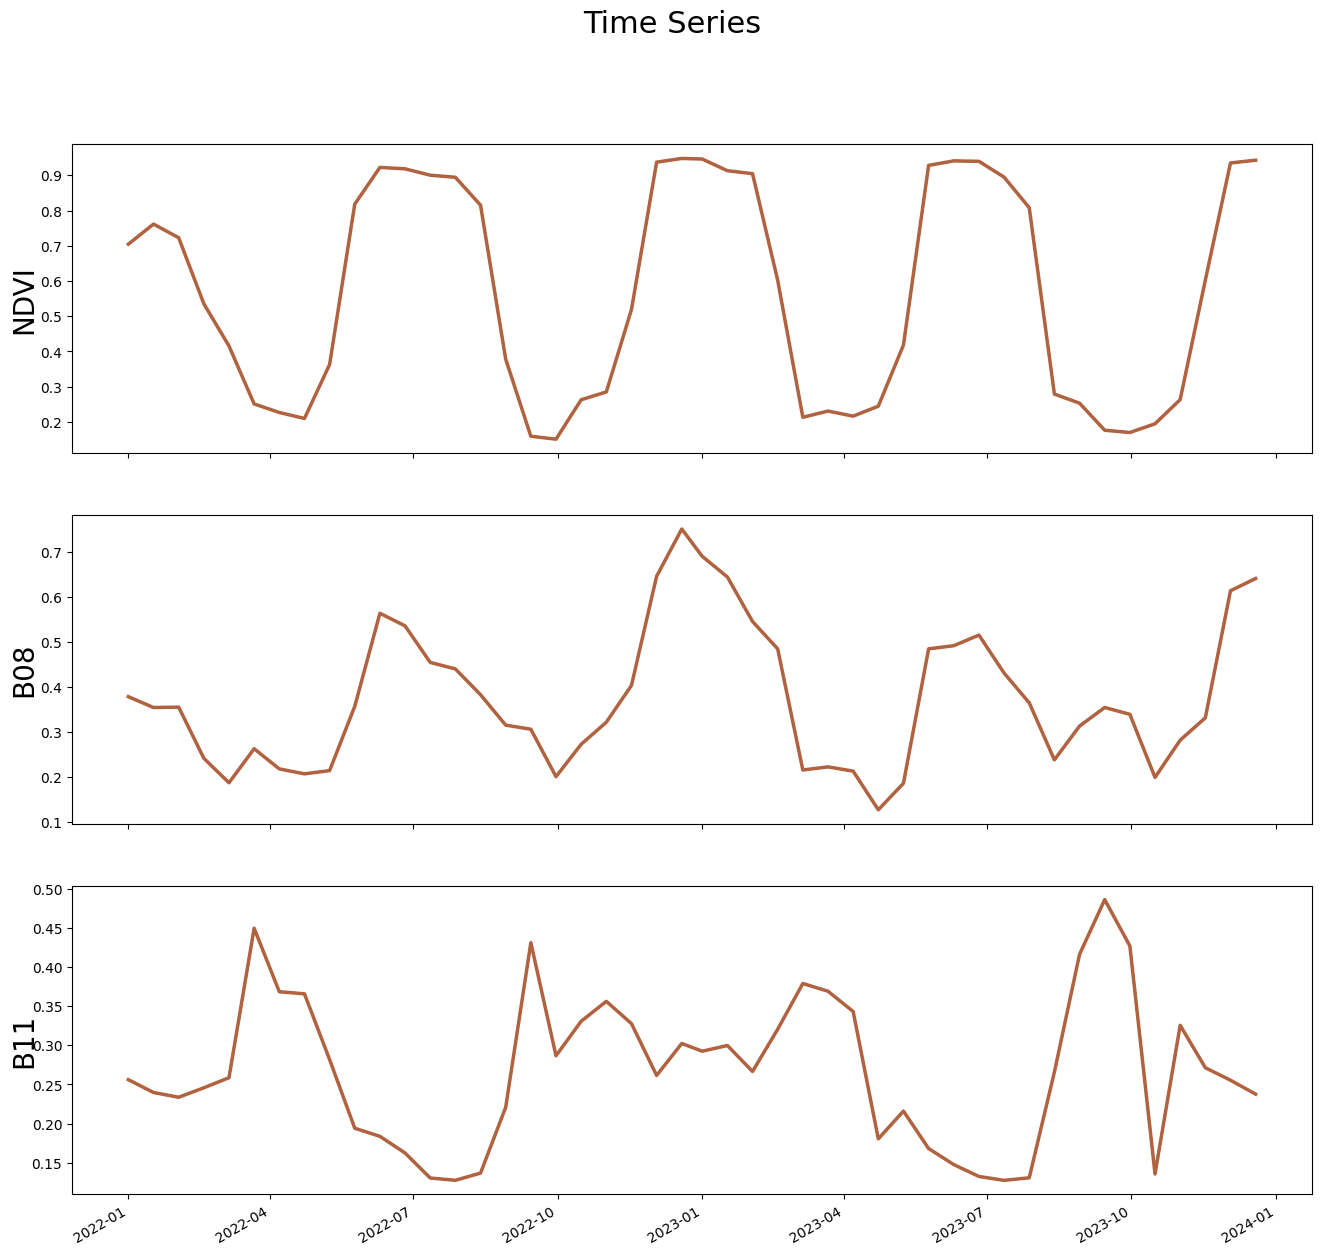

In [ ]:
ts_search.plot()

O eixo do tempo, com os valores de datas, pode ser acessado com a propriedade `timeline`:

In [ ]:
ts.timeline

['2022-01-01',
 '2022-01-17',
 '2022-02-02',
 '2022-02-18',
 '2022-03-06',
 '2022-03-22',
 '2022-04-07',
 '2022-04-23',
 '2022-05-09',
 '2022-05-25',
 '2022-06-10',
 '2022-06-26',
 '2022-07-12',
 '2022-07-28',
 '2022-08-13',
 '2022-08-29',
 '2022-09-14',
 '2022-09-30',
 '2022-10-16',
 '2022-11-01',
 '2022-11-17',
 '2022-12-03',
 '2022-12-19',
 '2023-01-01',
 '2023-01-17',
 '2023-02-02',
 '2023-02-18',
 '2023-03-06',
 '2023-03-22',
 '2023-04-07',
 '2023-04-23',
 '2023-05-09',
 '2023-05-25',
 '2023-06-10',
 '2023-06-26',
 '2023-07-12',
 '2023-07-28',
 '2023-08-13',
 '2023-08-29',
 '2023-09-14',
 '2023-09-30',
 '2023-10-16',
 '2023-11-01',
 '2023-11-17',
 '2023-12-03',
 '2023-12-19']

Os nomes dos atributos recuperados nas séries pode ser acessados pela propriedade `attributes`:

In [ ]:
ts.attributes

['NDVI', 'B08', 'B11']

E os valores da série para cada atributo podem ser recuperados pelo método `values`:

In [ ]:
ts.values('NDVI')[0]

[0.7046,
 0.7615,
 0.7228,
 0.5354,
 0.4156,
 0.2511,
 0.2269,
 0.2099,
 0.363,
 0.8182,
 0.9224,
 0.9183,
 0.9003,
 0.8943,
 0.8152,
 0.3782,
 0.1595,
 0.1511,
 0.263,
 0.2852,
 0.5191,
 0.9373,
 0.9478,
 0.9461,
 0.913,
 0.9046,
 0.6021,
 0.2133,
 0.2309,
 0.2165,
 0.2448,
 0.4184,
 0.9281,
 0.9409,
 0.9396,
 0.8947,
 0.808,
 0.2791,
 0.2533,
 0.1765,
 0.1701,
 0.1948,
 0.2634,
 0.6023,
 0.935,
 0.9428]

# Filtragem ou Remoção de Ruídos
<hr style="border:1px solid #0077b9;">

<br/><br/>

A biblioteca `scipy` se baseia na biblioteca `NumPy` e fornece funções adicionais para várias operações matemáticas e científicas, incluindo processamento de sinais e filtragem, dentre outras. Abaixo, são listados alguns módulos e funcionalidades que o SciPy oferece:

- Álgebra Linear (scipy.linalg).

- Otimização (scipy.optimize).

- Integração e EDOs (scipy.integrate).

- Interpolação (scipy.interpolate).

- Transformadas (scipy.fft).

- Estatísticas (scipy.stats).

- Processamento de Sinais (scipy.signal): Funções para processamento de sinais, incluindo filtros e análise de sistemas. Na filtragem abaixo iremos utilizar o módulo `scipy.signal` para aplicar o filtro **Savitzky–Golay** sobre as séries temporais obtidas.

In [ ]:
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
window_size = 8

poly_order = 5

ndvi_smooth = savgol_filter(ts.values('NDVI'), window_size, poly_order)
ndvi_smooth.T.shape

(46, 1)

In [ ]:
np.linspace(0, len(ts.timeline), num=23, endpoint=True)

array([ 0.        ,  2.09090909,  4.18181818,  6.27272727,  8.36363636,
       10.45454545, 12.54545455, 14.63636364, 16.72727273, 18.81818182,
       20.90909091, 23.        , 25.09090909, 27.18181818, 29.27272727,
       31.36363636, 33.45454545, 35.54545455, 37.63636364, 39.72727273,
       41.81818182, 43.90909091, 46.        ])

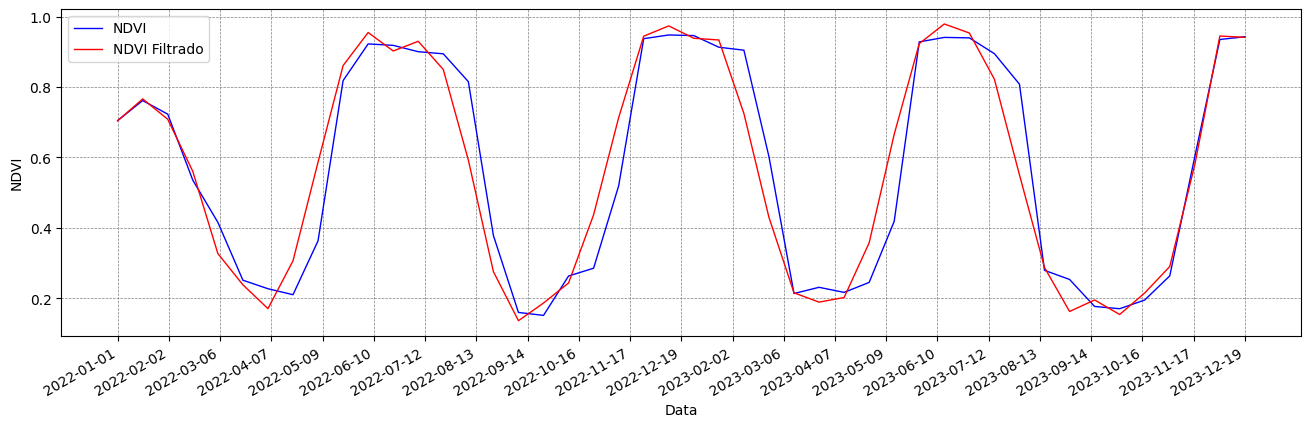

In [ ]:
fig = plt.figure( figsize=plt.figaspect(0.3) )

plt.xlabel('Data')
plt.ylabel('NDVI')

#plt.xticks(ticks=np.arange(len(ts.timeline)), labels=ts.timeline)
plt.xticks(np.linspace(0, len(ts.timeline) - 1, num=23, endpoint=True))

plt.plot(ts.timeline, ts.values('NDVI')[0], color="blue", linewidth=1.0, label='NDVI')

plt.plot(ts.timeline, ndvi_smooth.T, color="red", linewidth=1.0, label='NDVI Filtrado')

plt.grid(visible=True, color='gray', linestyle='--', linewidth=0.5)

plt.legend()

fig.autofmt_xdate()

plt.show()

# Recuperando a Série Temporal de Algumas Glebas
<hr style="border:1px solid #0077b9;">

<br/><br/>

Nesta seção vamos apresentar as séries temporais associadas à área de uma gleba. Iremos realizar a leitura dos dados da gleba associada ao `ref_bacen` número `515126640` no arquivo GeoPackage `glebas-wtss.gpkg`. A célula abaixo apresenta como realizar a operação de leitura desse arquivo:

In [ ]:
glebas = gpd.read_file("https://raw.githubusercontent.com/GSansigolo/shapefiles/refs/heads/main/glebas-wtss.gpkg", layer='glebas_pr_2022')
glebas.head(3)

,gid,gleba_gid,ref_bacen,nu_ordem,nu_indice,data_emissao_contrato,area_gleba,perimetro_gleba,area_menor_retangulo_envolvente,area_menor_circulo_envolvente,produto,ope_inicio_plantio,ope_fim_plantio,ope_inicio_colheita,ope_fim_colheita,cop_inicio_plantio,cop_fim_plantio,cop_inicio_colheita,cop_fim_colheita,rcp_inicio_plantio,rcp_fim_plantio,rcp_inicio_colheita,rcp_fim_colheita,rcp_inicio_evento,rcp_fim_evento,proagro_evento,proagro_status,geometry
0,2115,4445466,513320941,1,0,2022-01-03,2.114237e+05,2904.238901,4.507437e+05,6.477477e+05,milho,2022-02-20,2022-02-28,2022-07-20,2022-08-02,2022-02-20,2022-02-28,2022-07-20,2022-08-02,2022-02-20,2022-02-28,2022-08-15,2022-08-22,2022-05-01,2022-06-28,doença ou praga,deferida,"POLYGON ((-52.42006 -23.9753, -52.42016 -23.97..."
1,26731,4564138,513568219,1,0,2022-03-14,9.924504e+05,5662.308854,1.619530e+06,3.825708e+06,milho,2022-02-22,2022-02-28,2022-07-15,2022-07-30,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,None,None,"POLYGON ((-52.41854 -23.98168, -52.41862 -23.9..."
2,38224,4635279,513714304,1,0,2022-04-14,1.527261e+06,5056.193969,2.057616e+06,2.759834e+06,feijão,2022-04-09,2022-04-10,2022-07-05,2022-07-20,2022-04-09,2022-04-10,2022-08-04,2022-08-10,2022-04-09,2022-04-10,2022-08-03,2022-08-10,2022-06-11,2022-06-24,chuva excessiva,deferida,"POLYGON ((-52.39632 -23.96353, -52.39817 -23.9..."


As geometrias contidas no GeoDataFrame `glebas` encontram-se associadas ao CRS 4674:

In [ ]:
glebas.crs

<Geographic 2D CRS: EPSG:4674>
Name: SIRGAS 2000
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: Latin America - Central America and South America - onshore and offshore. Brazil - onshore and offshore.
- bounds: (-122.19, -59.87, -25.28, 32.72)
Datum: Sistema de Referencia Geocentrico para las AmericaS 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

Para facilitar os próximos passos, iremos transformar essas geometrias para o CRS 4326:

In [ ]:
glebas.to_crs('EPSG:4326', inplace=True)
glebas.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [ ]:
glebas.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

Paa recuperar a linha do GeoDataFrame com os dados da gleba com `ref_bacen` 515126640, podemos fazer:

In [ ]:
ref_bacen = 515126640

gleba = glebas[glebas['ref_bacen'] == ref_bacen]

gleba

,gid,gleba_gid,ref_bacen,nu_ordem,nu_indice,data_emissao_contrato,area_gleba,perimetro_gleba,area_menor_retangulo_envolvente,area_menor_circulo_envolvente,produto,ope_inicio_plantio,ope_fim_plantio,ope_inicio_colheita,ope_fim_colheita,cop_inicio_plantio,cop_fim_plantio,cop_inicio_colheita,cop_fim_colheita,rcp_inicio_plantio,rcp_fim_plantio,rcp_inicio_colheita,rcp_fim_colheita,rcp_inicio_evento,rcp_fim_evento,proagro_evento,proagro_status,geometry
17,196683,5453196,515126640,1,0,2022-11-30,69941.863227,1233.11931,99476.124916,227264.173989,milho,2023-02-15,2023-02-28,2023-07-22,2023-08-10,2023-02-25,2023-02-25,2023-07-01,2023-08-30,2023-02-25,2023-02-25,2023-08-18,2023-08-28,2023-04-26,2023-06-12,seca,deferida,"POLYGON ((-52.41096 -23.96769, -52.41322 -23.9..."


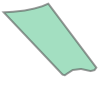

In [ ]:
gleba.geometry.iloc[0]

Antes de recuperar a série temporal associada à gleba com `ref_bacen` 515126640, vamos gerar um mapa com o `ipyleaflet` e visualizar essa gleba. Para isso, precisaremos consultar o catálogo STAC, visto anteriormente, por imagens da região.

In [ ]:
!pip install pystac-client==0.8.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 8.1 MB/s eta 0:00:00


In [ ]:
from pystac_client import Client

catalogo = Client.open("https://data.inpe.br/bdc/stac/v1/")
catalogo

<Client id=INPE>

In [ ]:
bbox_gleba = gleba.geometry.iloc[0].bounds


item_search = catalogo.search(
    collections=['S2_L2A-1'],
    bbox=bbox_gleba,
    datetime='2023-07-01/2023-07-31',
    query={
        "eo:cloud_cover": {
            "lt" : 10
        }
    },
    limit = 100
)

item_search.matched()

6

In [ ]:
items = item_search.item_collection()
items

In [ ]:
assets = items[0].assets
assets

{'AOT': <Asset href=https://data.inpe.br/bdc/data/S2_L2A/v001/22/K/CU/2023/7/S2B_AOT_20230731T133149_N0509_R081_T22KCU_20230731T160106.tif>,
 'B01': <Asset href=https://data.inpe.br/bdc/data/S2_L2A/v001/22/K/CU/2023/7/S2B_B01_20230731T133149_N0509_R081_T22KCU_20230731T160106.tif>,
 'B02': <Asset href=https://data.inpe.br/bdc/data/S2_L2A/v001/22/K/CU/2023/7/S2B_B02_20230731T133149_N0509_R081_T22KCU_20230731T160106.tif>,
 'B03': <Asset href=https://data.inpe.br/bdc/data/S2_L2A/v001/22/K/CU/2023/7/S2B_B03_20230731T133149_N0509_R081_T22KCU_20230731T160106.tif>,
 'B04': <Asset href=https://data.inpe.br/bdc/data/S2_L2A/v001/22/K/CU/2023/7/S2B_B04_20230731T133149_N0509_R081_T22KCU_20230731T160106.tif>,
 'B05': <Asset href=https://data.inpe.br/bdc/data/S2_L2A/v001/22/K/CU/2023/7/S2B_B05_20230731T133149_N0509_R081_T22KCU_20230731T160106.tif>,
 'B06': <Asset href=https://data.inpe.br/bdc/data/S2_L2A/v001/22/K/CU/2023/7/S2B_B06_20230731T133149_N0509_R081_T22KCU_20230731T160106.tif>,
 'B07': <Asse

In [ ]:
tci_asset = assets['TCI']
tci_asset.href

'https://data.inpe.br/bdc/data/S2_L2A/v001/22/K/CU/2023/7/S2B_TCI_20230731T133149_N0509_R081_T22KCU_20230731T160106.tif'

Agora, precisamos preparar as camadas que serão apresentadas sobre o mapa:

In [ ]:
camada_cena = TileLayer(
    name=items[0].id,
    url="https://data.inpe.br/bdc/tms/tiles/WebMercatorQuad/{z}/{x}/{y}" + f"?url={tci_asset.href}"
)

In [ ]:
camada_gleba = GeoJSON(
    name="Polígono da Gleba",
    data=shapely.geometry.mapping(gleba.geometry.iloc[0]),
    style={ 'color': 'SteelBlue', 'opacity': 1, 'fillOpacity': 0.1, 'weight': 5 },
    hover_style={ 'color': 'IndianRed', 'opacity': 1, 'fillOpacity': 0.1, 'weight': 5 }
)

In [ ]:
mapa_tms = Map(zoom=16, scroll_wheel_zoom=True, layout=Layout(width='80%', height='500px'))

mapa_tms.add(camada_cena)
mapa_tms.add(camada_gleba)

mapa_tms.add(LayersControl(position='topright'))
mapa_tms.add(FullScreenControl())
mapa_tms.add(ScaleControl(position='bottomleft'))

mapa_tms.fit_bounds([[bbox_gleba[1], bbox_gleba[0]], [bbox_gleba[3], bbox_gleba[2]]])

display(mapa_tms)

Finalmente, vamos recuperar a série temporal da gleba apresentada no mapa acima:

In [ ]:
ts_search = cubo_s2.ts(attributes=('NDVI', 'B08', 'B11'),
                       geom=gleba.geometry.iloc[0],
                       start_date='2022-01-01', end_date='2022-12-31')
ts_search

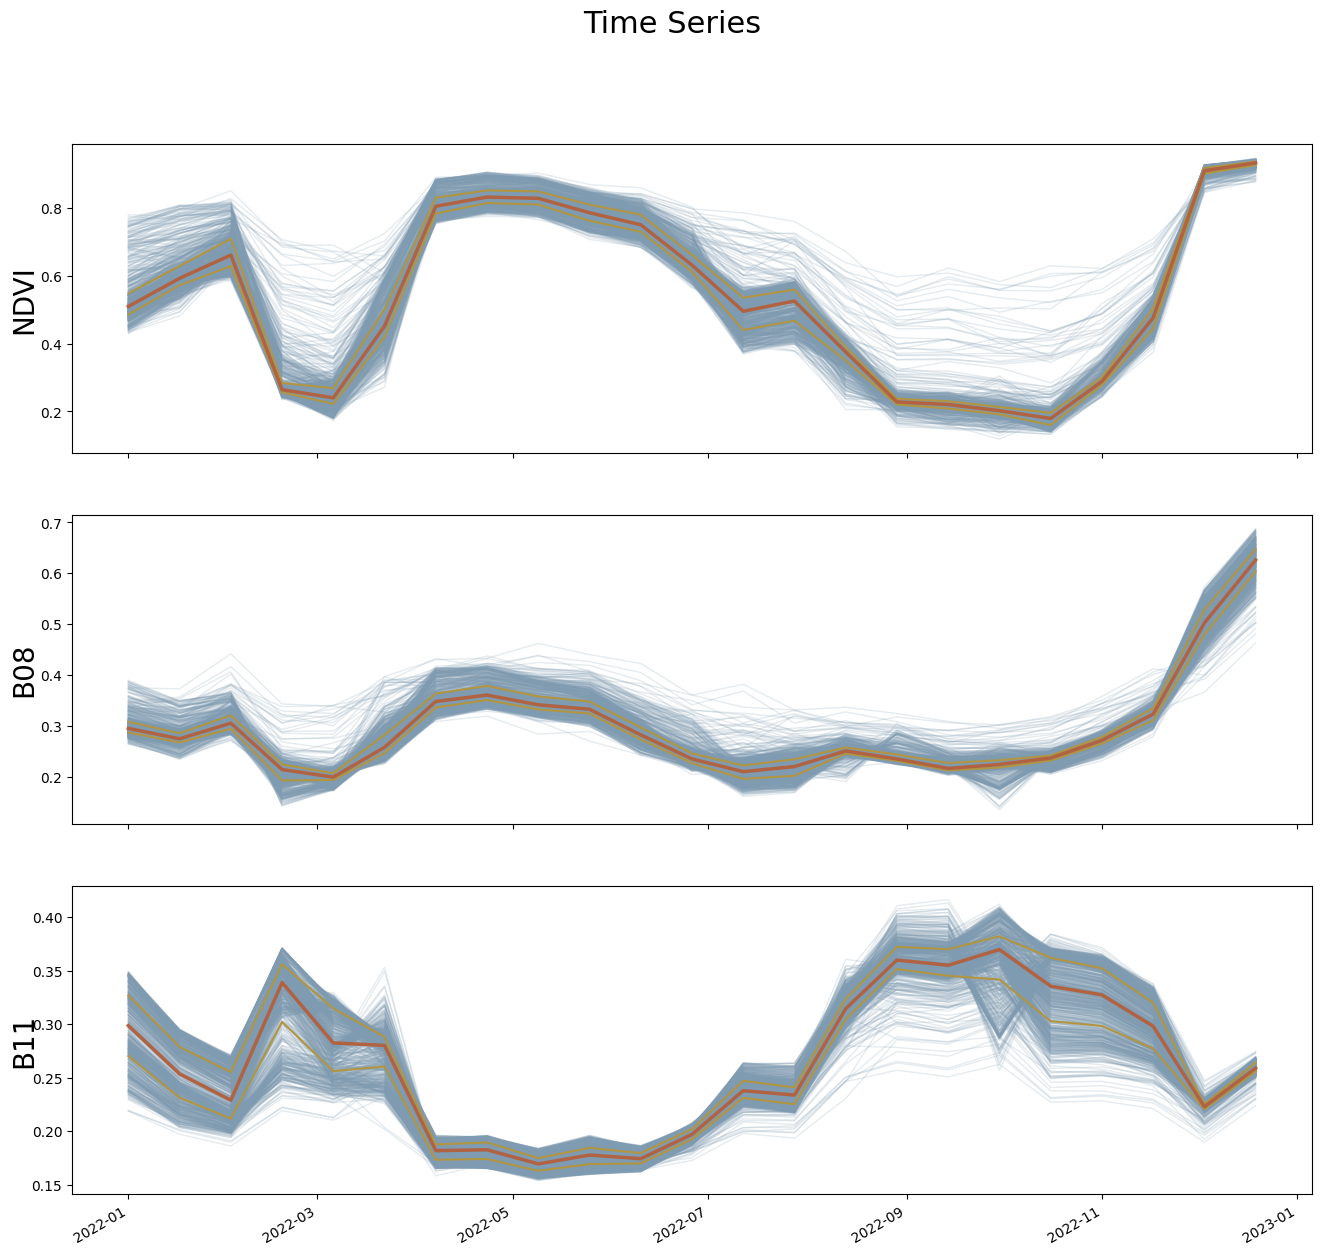

In [ ]:
ts_search.plot()

Apenas para ilustrar, vamos passar um filtro em todas séries de NDVI recuperadas:

In [ ]:
ts = ts_search.ts
ts

In [ ]:
window_size = 5

poly_order = 3

ndvi_smooth = savgol_filter(ts.values('NDVI'), window_size, poly_order)
ndvi_smooth.T

In [ ]:
fig = plt.figure( figsize=plt.figaspect(0.3) )

plt.xlabel('Data')
plt.ylabel('NDVI')

plt.xticks(np.linspace(0, len(ts.timeline) - 1, num=23, endpoint=True))

for values in ts.values('NDVI'):
    plt.plot(ts.timeline, values, color="#87CEFA", linewidth=1.0, alpha=0.6)

plt.grid(visible=True, color='gray', linestyle='--', linewidth=0.5)

fig.autofmt_xdate()

plt.show()

In [ ]:
fig = plt.figure( figsize=plt.figaspect(0.3) )

plt.xlabel('Data')
plt.ylabel('NDVI Filtrado')

plt.xticks(np.linspace(0, len(ts.timeline) - 1, num=23, endpoint=True))

for values in ndvi_smooth:
    plt.plot(ts.timeline, values, color="red", linewidth=1.0)

plt.grid(visible=True, color='gray', linestyle='--', linewidth=0.5)

fig.autofmt_xdate()

plt.show()

# Referências
<hr style="border:1px solid #0077b9;">

- [Python Client Library for Web Time Series Service - User Guide](https://wtss.readthedocs.io/en/latest/index.html)


- [Python Client Library for Web Time Series Service - GitHub Repository](https://github.com/brazil-data-cube/wtss.py)


- [WTSS OpenAPI 3 Specification](https://github.com/brazil-data-cube/wtss-spec)


- VINHAS, L.; QUEIROZ, G. R.; FERREIRA, K. R.; CÂMARA, G. [Web Services for Big Earth Observation Data](http://www.seer.ufu.br/index.php/revistabrasileiracartografia/article/view/44004). Revista Brasileira de Cartografia, v. 69, n. 5, 18 maio 2017.